# The Big Titanic Challenge - Who survived, who died?

It's time to get our hands dirty and do some Machine Learning!
Who will find the best model to predict survival and death on the Titanic? Let's find out...

## Shoutouts:

This homework is based on the Titanic challenge on Kaggle: https://www.kaggle.com/c/titanic

## General Description (taken from Kaggle)

The sinking of the Titanic is one of the most infamous shipwrecks in history.

On April 15, 1912, during her maiden voyage, the widely considered “unsinkable” RMS Titanic sank after colliding with an iceberg. Unfortunately, there weren’t enough lifeboats for everyone onboard, resulting in the death of 1502 out of 2224 passengers and crew.

While there was some element of luck involved in surviving, it seems some groups of people were more likely to survive than others.

In this challenge, we ask you to build a predictive model that answers the question: “what sorts of people were more likely to survive?” using passenger data (ie name, age, gender, socio-economic class, etc).

## The Task

This notebook will help us to exercise the process of model selection on a simple example. You will find a detailed task description further down in this notebook.


## Prerequisites

To run this notebook you should have the following libraries installed:
- numpy: an optimized library for dealing with tensor data
- pandas: a library for loading and modifying tabular datasets
- sklearn: the machine learning library we will use.

This notebook is designed to be opened in Google Colab. If you execute it on your own computer you may have to install additinal dependencies - e.g., the tool wget which is used for downloading the dataset.

## Imports

In [3]:
!pip3 install scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 4.9 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.5/20.5 MB 16.4 MB/s  0:00:01m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [scikit-learn] [scikit-learn]


In [4]:
# Data Processing
import numpy as np
import pandas as pd

# ML Algorithms
import sklearn
from sklearn.linear_model import LogisticRegression
from sklearn import neighbors
from sklearn import svm
from sklearn import tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier


## The dataset

For this exercise we will load data that has been preprocessed already. During the preprocessing we have taken care of missing values and removed / refactored some of the columns to make the data easier to use for this exercise.

Here are the features of this dataset:
* Survived: 0=died, 1=survived
* Sex: 0=male, 1=female
* Embarked: Port of embarkment, 0=Southhampton, 1=Cherbourg, 2=Queenstown
* Title: 0=Mr, 1=Mrs, 2=Miss, 3=Master, 4=Royalty, 5=Officer
* AgeBin: 0=Baby, 1=Child, 2=Teenager, 3=Young Adult, 4=Adult, 5=Senior
* Family_Alone {Family_Small} [Family_Large]: 1=Passenger travelled alone {with 1 to 3 family members aboard} [with more than 4 family members aboard], 0=otherwise
* Pclass_ordinal: Ticket class, 1=1st class, 2=2nd class, 3=3rd class
* The rest is [dummy codings](https://en.wikiversity.org/wiki/Dummy_variable_(statistics)) of Pclass_ordinal, AgeBin, and Title. Wonder why one dummy is always missing? Read [here](https://www.algosome.com/articles/dummy-variable-trap-regression.html) about the dummy variable trap.

In [8]:
# Get data from Google Drive
!mkdir -p input
!curl -L 'https://drive.google.com/uc?export=download&id=1JSSkzCveHYangek7W26tZYcg--prxTVG' -o 'input/data.csv'

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 42846  100 42846    0     0  24726      0  0:00:01  0:00:01 --:--:--  111k


In [9]:
# Read train and test data into Pandas DataFrames
data = pd.read_csv('input/data.csv')
data.sample(5)

data.drop(['FareClass'], axis=1, inplace=True)

# print five random data points as example
data.sample(5)

,Unnamed: 0,Survived,Sex,Embarked,Title,AgeBin,Family_Alone,Family_Small,Family_Large,Pclass_ordinal,...,Title_1,Title_2,Title_3,Title_4,Title_5,Age_1,Age_2,Age_3,Age_4,Age_5
761,761,0,0,0,0,4,1,0,0,3,...,0,0,0,0,0,0,0,0,1,0
390,390,1,0,0,0,4,0,1,0,1,...,0,0,0,0,0,0,0,0,1,0
636,636,0,0,0,0,3,1,0,0,3,...,0,0,0,0,0,0,0,1,0,0
290,290,1,1,0,2,3,1,0,0,1,...,0,1,0,0,0,0,0,1,0,0
37,37,0,0,0,0,3,1,0,0,3,...,0,0,0,0,0,0,0,1,0,0


The loaded data is part of the training data from the Kaggle challenge.

We'll do some more preprocessing steps here:
- Reduce the dimensionality of the data (pick specific features only)
- Split into input (X) and output(y) data.
- Split into trainin data (X_train, y_train) and test data (X_test, y_test).

In [10]:
# Pick the features we would like to use for our model
feature_cols = ["Sex", "Embarked", "Title", "AgeBin", "Family_Alone", "Family_Small", "Family_Large", "Pclass_ordinal"]

# split into input (X) and output (y)
X, y = data[feature_cols], data["Survived"]

# Automatically split the data into train and test data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

print(X_test.shape)

(179, 8)


## A simple model: Logistic Regression

Now let's train a simple model: Logistic Regression.
Since we are using sklearn, this is quite easy, as the most common machine learning models have already been implemented. So all we have to do is:
- Instantiate the model and configure it with [hyper-parameters](https://en.wikipedia.org/wiki/Hyperparameter_(machine_learning))
- train the model
- print out the result


The metric we have used in the cell below is Accuracy. Simply speaking, this is the probability of the model to guess correctly. The traing accuracy is the accuracy of the model based on the training data, while the test accuracy is based on the test set. The test accuracy is the more important one because the model has not seen these values during training.

In [11]:
# Define the model and its hyper parameters
model = LogisticRegression(C=1, max_iter=50)

# train the model
model.fit(X_train, y_train)

# print training set accuracy
train_acc_log = round(model.score(X_train, y_train) * 100, 2)
print("Prediction accuracy (Training Set):", train_acc_log, "%\n")

# Check and print prediction accuracy
test_acc_log = round(model.score(X_test, y_test) * 100, 2)
print("Prediction accuracy (Test Set):", test_acc_log, "%\n")


Prediction accuracy (Training Set): 83.29 %

Prediction accuracy (Test Set): 79.89 %



## Your Playground

### Task: Play around with different models

The below cell is a place for you to practice model selection. unnily enough, as long as you stick with sklearn this mostly means altering one specific line from the logistic regression to specify a different combination of model and hyper parameters.

Your task consists of two parts:
1) Experiment with 3 or more different models and note down the scores you achieved.
2) For the best model you achieved, research how this model works and which hyper-parameters it has. Then experiment with different values for these hyper parameters to find out which ones work best.

Below the cell is a text cell where you can keep notes about your experiment results.

Some tips for this task:
- You can find all supervised learning models from sklearn here:  https://scikit-learn.org/stable/supervised_learning.html Keep in mind that this is a classification problem. You should be testing only classification models.
- You can see an example of a model and its hyper parameters in the logistic regression cell above.
- You want to make decisions based on test accuracy, not training accuracy.
- remember that you have to import the model you want to use first. A few likely candidates are already imported in the beginning of this notebook.


In [229]:
# Define the model and its hyper parameters

# TODO: your model definition goes here.
model = RandomForestClassifier(bootstrap=True)

# train the model
model.fit(X_train, y_train)

# print trainin set accuracy
train_acc_log = round(model.score(X_train, y_train) * 100, 2)
print("Prediction accuracy (Training Set):", train_acc_log, "%\n")

# Check and print prediction accuracy
test_acc_log = round(model.score(X_test, y_test) * 100, 2)
print("Prediction accuracy (Test Set):", test_acc_log, "%\n")

Prediction accuracy (Training Set): 86.8 %

Prediction accuracy (Test Set): 79.33 %



### Your Notes:

**tree.DecisionTreeClassifier()**
_Learning decision rules based on the data features_

| Setting | Hyperparameter | Training Set | Test Set |
| ------- | -------- | ------------ | ------------ |
| Default | - | 86,8% | 78.21% |
| min_samples_split: 88-131 | The minimum number of samples required to split an internal node | 83,99% | 80,45% |

**neighbors.KNeighborsClassifier**
_Tests against nearest neighbor training samples based on the k-earest neighbors of each point_

| Setting | Hyperparameter | Training Set | Test Set |
| ------- | -------- | ------------ | ------------ |
| Default | - | 85,11% | 79.33% |
| algorithm='ball_tree', leaf_size=12 | BallTree Algorithm with 12 to determine speed of construction | 85,25% | 81,56% |

**svm.LinearSVC()**
_Finds optimal line and optimizes the error margin_

| Setting | Hyperparameter | Training Set | Test Set |
| ------- | -------- | ------------ | ------------ |
| Default | - | 83,43% | 79.89% |
| class_weight='balanced', max_iter=20 | 82,44% | 80,45% |

**RandomForestClassifier()**
_DecisionTreeClassifier on to of multiple sub-samples of the dataset._

| Setting | Hyperparameter | Training Set | Test Set |
| ------- | -------- | ------------ | ------------ |
| Default | - | 86,8% | 79.33% |
| min_samples_split=60 / max_depth=3 | 83,71% | 81,1% | 

## Evaluating Models

Accuracy is a pretty basic error metric. Depending on what you want to use your model for, different metrics are relevant. The below cell calculates what is called a Confusion Matrix, as well as the metrics precision, recall and F1 score. We will discuss these during our next Learning Unit session.

/var/folders/5_/0wmfbw9s5y34jq82848gv2qw0000gn/T/ipykernel_86879/986170740.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(labels)
/var/folders/5_/0wmfbw9s5y34jq82848gv2qw0000gn/T/ipykernel_86879/986170740.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_yticklabels(labels)


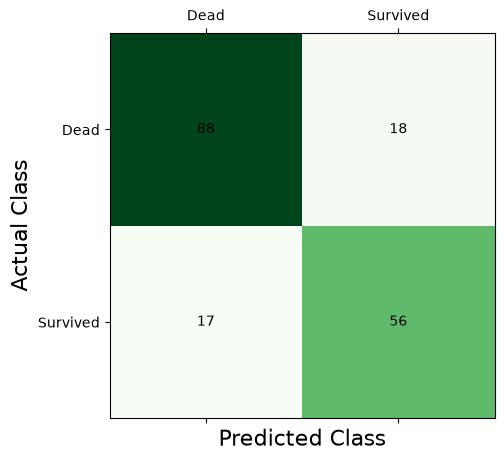

precision: 0.7567567567567568
recall: 0.7671232876712328
F1 Score:  0.761904761904762


In [168]:
import matplotlib.pyplot as plt      # MATLAB like plotting routines
from sklearn.metrics import confusion_matrix

# calculate confusion matrix
Y_pred = model.predict(X_test)
Y_pred_classes = np.argmax(Y_pred)
cm = confusion_matrix(y_test, Y_pred)

#create and plot confusion matrix figure content
fig, ax = plt.subplots(figsize=(5, 5))
labels = ['','Dead','Survived']
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)
ax.matshow(cm, cmap=plt.cm.Greens)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(x=j, y=i,s=cm[i, j], va='center', ha='center')

plt.xlabel('Predicted Class', fontsize=16)
plt.ylabel('Actual Class', fontsize=16)
plt.show()

#print precision & recall
precision = cm[1][1] / (cm[0][1] + cm[1][1]) # true prositives / predicted positives
recall = cm[1][1] / (cm[1][0] +cm[1][1]) # true positives / actual prositives
f1 = 2*(precision*recall)/(precision + recall) # harmoic mean of precision & recall

print("precision:", precision)
print("recall:", recall)
print("F1 Score: ", f1)
